In [302]:
from langchain_ollama import ChatOllama
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langgraph.graph import StateGraph as GraphBuilder, END , START
import chromadb
from langchain_ollama import OllamaEmbeddings
from pydantic import BaseModel, Field
from langchain_tavily import TavilySearch as TavilySearchTool
from typing import List, Dict, Annotated, TypedDict
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder, SystemMessagePromptTemplate, HumanMessagePromptTemplate, PromptTemplate  
from dotenv import load_dotenv


In [275]:
load_dotenv()

True

In [303]:
tavily_search_tool = TavilySearchTool(
    max_results=1,
)

In [277]:
embedding_model = OllamaEmbeddings(model = "all-minilm:33m")
answer_llm = ChatOllama(model = "phi4-mini:latest")

In [278]:
client = chromadb.PersistentClient(path="./chroma_db")

In [279]:
collection = client.get_or_create_collection(name="my_chunks")

In [280]:
path = r"C:\Users\user\Desktop\Project\ContextAgent\data\COMPLETE_DSA_MASTERY_ROADMAP_FORMATTED.pdf"

In [281]:
loader = PyPDFLoader(path)
documents = loader.load()

In [282]:
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=5)

In [283]:
chunks = splitter.split_documents(documents)

In [284]:
embeddings = embedding_model.embed_documents([chunk.page_content for chunk in chunks])

In [285]:
for c in chunks:
    print(c)

page_content='COMPLETE DSA MASTERY ROADMAP
For Landing a Job in Top Tech Companies
Your Current Situation Assessment
 You have theoretical knowledge from CSIT coursework (DSA and DAA)✅
 You understand concepts but need to translate theory into problem-solving✅
 You're ready for structured, consistent practice (2-3 problems/day✅
 PHASE-WISE DSA ROADMAP🗺️
PHASE 1: THE FOUNDATION
Duration: 1.5 - 2 months
Goal: Reinforce basic data structures and master common operations' metadata={'producer': 'LibreOffice 24.2', 'creator': 'Writer', 'creationdate': '2026-02-25T14:12:27+00:00', 'author': 'Un-named', 'source': 'C:\\Users\\user\\Desktop\\Project\\ContextAgent\\data\\COMPLETE_DSA_MASTERY_ROADMAP_FORMATTED.pdf', 'total_pages': 9, 'page': 0, 'page_label': '1'}
page_content='Topic Key Concepts to Master Problem Types to Practice
Arrays & Strings
Traversal techniques • 
Insertion/Deletion • Prefix Sum • 
Two Pointers • Sliding Window
Subarray problems • String 
manipulation • Two-sum variations •

In [286]:
ids = [f"chunk-{i}" for i in range(len(chunks))]
documents_for_chroma = [chunk.page_content for chunk in chunks]
metadatas_for_chroma = [chunk.metadata for chunk in chunks]

collection.add(
    ids=ids,
    embeddings=embeddings,
    documents=documents_for_chroma,
    metadatas=metadatas_for_chroma,
)

In [288]:
class State(TypedDict):
    query: str
    answer: str
    response: str
    tool_calls: bool
    suggestion: List[str]

In [289]:
def chat_node(state: State):
    query = state.get("query", "").strip()
    if not query:
        return {
            "query": "",
            "answer": "Please provide a query.",
            "tool_calls": True,
            "suggestion": ["Ask a clear question so I can retrieve context."],
        }

    query_vector = embedding_model.embed_query(query)
    results = collection.query(
        query_embeddings=[query_vector],
        n_results=3,
    )

    retrieved_docs = results.get("documents", [[]])[0] if results.get("documents") else []
    usable_docs = [doc for doc in retrieved_docs if isinstance(doc, str) and doc.strip()]
    should_call_tool = len(usable_docs) == 0

    if should_call_tool:
        return {
            "query": query,
            "answer": "",
            "tool_calls": True,
            "suggestion": ["No relevant context found in vector DB. Trigger the tool node."],
        }

    retrieved_text = "\n\n".join(usable_docs)
    prompt = PromptTemplate(
        template=(
            "You are a helpful RAG assistant. Use only the retrieved context to answer. "
            "If context is insufficient, say that clearly.\n\n"
            "Retrieved documents:\n{retrieved_docs}\n\n"
            "User query: {user_query}"
        ),
        input_variables=["retrieved_docs", "user_query"],
    )

    formatted_prompt = prompt.format(
        retrieved_docs=retrieved_text,
        user_query=query,
    )

    answer_msg = answer_llm.invoke(formatted_prompt)
    answer_text = answer_msg.content if hasattr(answer_msg, "content") else str(answer_msg)

    return {
        "query": query,
        "answer": answer_text,
        "tool_calls": False,
        "suggestion": [],
    }

In [290]:
def tools_decider(state: State):
    condition = state["tool_calls"]
    if(condition):
        return "tool_node"
    else: 
        return "retriver_node"

In [298]:
def tool_node(state: State):
    query = state["query"]
    search_response = tavily_search_tool.invoke(query)
    results = search_response.get("results", [])

    if not results:
        return {"answer": "No web results found."}

    content = results[0].get("content", "No content found.")
    return {"answer": content}

In [292]:
query = "What is the roadmap for mastering DSA?"
query_embedded = embedding_model.embed_query(query)

results = collection.query(
    query_embeddings = query_embedded,
    n_results=1
)
results["documents"]

[["COMPLETE DSA MASTERY ROADMAP\nFor Landing a Job in Top Tech Companies\nYour Current Situation Assessment\n You have theoretical knowledge from CSIT coursework (DSA and DAA)✅\n You understand concepts but need to translate theory into problem-solving✅\n You're ready for structured, consistent practice (2-3 problems/day✅\n PHASE-WISE DSA ROADMAP🗺️\nPHASE 1: THE FOUNDATION\nDuration: 1.5 - 2 months\nGoal: Reinforce basic data structures and master common operations"]]

In [293]:
def retriver_node(state: State):
    query = state["query"]
    query_embedded = embedding_model.embed_query(query)
    result = collection.query(
        query_embeddings= query_embedded,
        n_results = 1
    )
    answer = result["documents"]
    return {
        "answer": answer
    }

In [299]:
def answer_node(state: State):
    query = state["query"]
    answer = state["answer"]
    prompt = PromptTemplate(
        template="""You are a helpful assistant. Answer the user query based on the provided context.
Query: {query}
Context: {answer}""",
        input_variables=["query", "answer"],
    )
    formatted_prompt = prompt.format(query=query, answer=answer)
    response_msg = answer_llm.invoke(formatted_prompt)
    response_text = response_msg.content if hasattr(response_msg, "content") else str(response_msg)
    return {"response": response_text}

In [300]:
def suggestion_node(state: State):
    response = state["response"]
    prompt = PromptTemplate(
        template="""You are a helpful assistant. Generate exactly 3 follow-up questions based on the query and response.
Query: {query}
Response: {response}
Return each question on a new line without numbering.""",
        input_variables=["query", "response"],
    )
    formatted_prompt = prompt.format(query=state["query"], response=response)
    suggestion_msg = answer_llm.invoke(formatted_prompt)
    suggestion_text = suggestion_msg.content if hasattr(suggestion_msg, "content") else str(suggestion_msg)
    suggestions = [line.strip(" -0123456789.") for line in suggestion_text.splitlines() if line.strip()]
    return {"suggestion": suggestions[:3]}

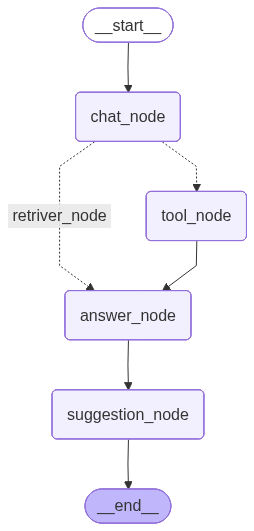

In [304]:

g = GraphBuilder(State)
g.add_node("chat_node", chat_node)
g.add_node("tool_node", tool_node)
g.add_node("answer_node", answer_node)
g.add_node("suggestion_node", suggestion_node)

g.add_edge(START, "chat_node")
g.add_conditional_edges(
    "chat_node",
    tools_decider,
    {
        "tool_node": "tool_node",
        "retriver_node": "answer_node",
    },
)
g.add_edge("tool_node", "answer_node")
g.add_edge("answer_node", "suggestion_node")
g.add_edge("suggestion_node", END)

graph = g.compile()
graph

In [305]:
test_state = {
    "query": "What is the roadmap for mastering DSA?",
    "answer": "",
    "response": "",
    "tool_calls": False,
    "suggestion": [],
}

output = graph.invoke(test_state)
output

{'query': 'What is the roadmap for mastering DSA?',
 'answer': 'The retrieved documents outline a Phase-Wise Data Structures and Algorithms (DSA) mastery road-map which includes:\n\n**PHASE 1: THE FOUNDATION**\n*Duration:* 1.5 - 2 months\n*Goal*: Reinforce basic data structures like arrays, strings, linked lists, stacks, queues, hashing; master common operations.\n\nYouTube channels such as Striver for in-depth explanations of complex topics can be helpful here.\nBooks to consider include "Cracking the Coding Interview" and "Introduction to Algorithms (CLRS)".\n\n**PHASE 2**\n*Duration:* Expected duration is not specified but would likely follow after Phase 1, spanning about another month or two based on consistent effort with a suggested goal of understanding recursion deeply. In this phase one can expect topics like Recursion, Backtracking, Searching, Sorting algorithms (like QuickSort and Merge Sort), Trees including Binary Search Tree & Heap.\n\nThe roadmap mentions platforms such 